In [ ]:
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
 
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"naubass","key":"971f5810f2bafc6d58b33c053aefdf0e"}'}

In [3]:
# Create the .kaggle directory
!mkdir -p ~/.kaggle

# Copy the kaggle.json file
!cp kaggle.json ~/.kaggle/

# Change permissions so the file is private
!chmod 600 ~/.kaggle/kaggle.json

# Download the Waste Classification Dataset
!kaggle datasets download -d nofalrafif/cat-skin-disease

# Unzip the dataset secara diam-diam (quiet mode)
!unzip -q cat-skin-disease.zip

Dataset URL: https://www.kaggle.com/datasets/nofalrafif/cat-skin-disease
License(s): unknown
100% 57.7M/57.7M [00:02<00:00, 26.8MB/s]



In [4]:
import os
import shutil

# direktori train & test
source_dir = "CAT SKIN DISEASE"

# gabungkan directory
combined_dir = "cat_skin_disease/dataset"

# buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

for category in os.listdir(source_dir):
    category_path = os.path.join(source_dir, category)

    # Pastikan yang diproses adalah folder, bukan file (seperti .zip atau .json)
    if os.path.isdir(category_path):
        print(f"Memproses kategori: {category}")
        dest_path = os.path.join(combined_dir, category)

        # Copy isi folder ke tempat baru
        if os.path.exists(dest_path):
            # Jika folder tujuan sudah ada, copy isinya satu per satu
            for file_name in os.listdir(category_path):
                shutil.copy(os.path.join(category_path, file_name), os.path.join(dest_path, file_name))
        else:
            shutil.copytree(category_path, dest_path)

print("Selesai! Semua data sudah digabungkan di:", combined_dir)

Memproses kategori: Health
Memproses kategori: Scabies
Memproses kategori: Flea_Allergy
Memproses kategori: Ringworm
Selesai! Semua data sudah digabungkan di: cat_skin_disease/dataset


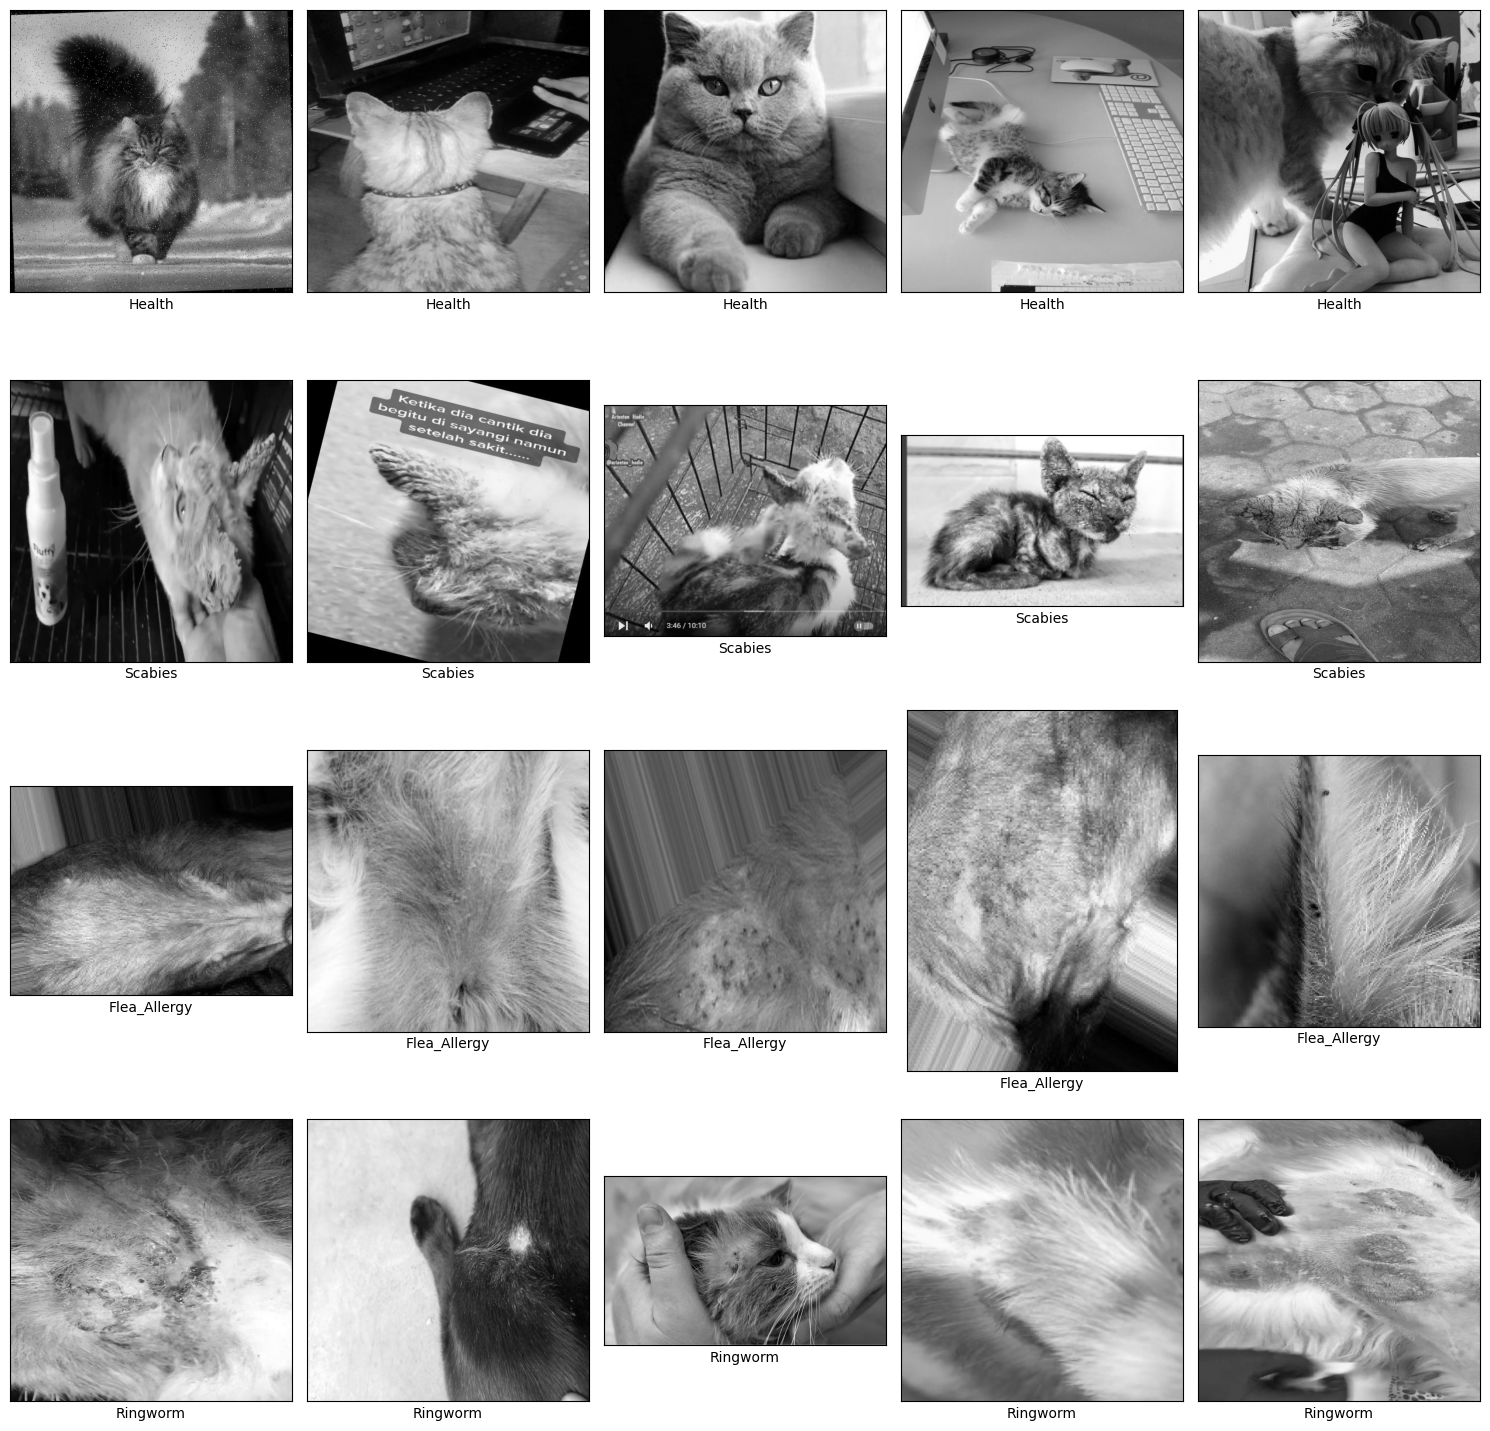

In [5]:
lung_image = {}

path = "cat_skin_disease/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    lung_image[i] = os.listdir(os.path.join(path_sub, i))

path_sub = "cat_skin_disease/dataset/"

# tampilkan 5 gambar random
fig, axs = plt.subplots(len(lung_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(lung_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

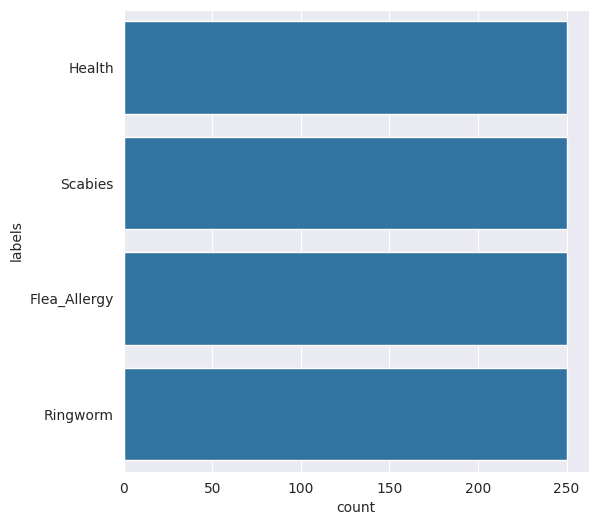

In [6]:
lung_path = "cat_skin_disease/dataset/"

# daftar menyimpan file
file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# plot jumlah gambar
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [7]:
import cv2
import numpy as np
import random
from skimage.transform import rotate
from scipy.ndimage import map_coordinates, gaussian_filter

IMG_SIZE = 224

def resize_img(img):
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

def random_rotation(img):
    img = resize_img(img)
    sudut = random.randint(-45, 45)
    return (rotate(img, sudut, mode='edge') * 255).astype(np.uint8)

def flip_horizontal(img):
    img = resize_img(img)
    return np.fliplr(img)

def flip_vertical(img):
    img = resize_img(img)
    return np.flipud(img)

def adjust_brightness_contrast(img):
    img = resize_img(img)
    alpha = random.uniform(0.8, 1.4)
    beta = random.randint(-20, 40)
    return np.clip(cv2.convertScaleAbs(img, alpha=alpha, beta=beta), 0, 255)

def blur_image(img):
    img = resize_img(img)
    return cv2.GaussianBlur(img, (3, 3), 0)

def random_zoom(img):
    img = resize_img(img)
    scale = random.uniform(0.85, 1.15)
    h, w = img.shape[:2]
    new_h, new_w = int(h * scale), int(w * scale)
    img_resized = cv2.resize(img, (new_w, new_h))
    if scale > 1.0:
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        return img_resized[start_h:start_h+h, start_w:start_w+w]
    else:
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        return cv2.copyMakeBorder(img_resized, pad_h, h-new_h-pad_h,
                                  pad_w, w-new_w-pad_w, cv2.BORDER_REPLICATE)

def color_jitter(img):
    img = resize_img(img)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[:,:,0] = (hsv[:,:,0] + random.uniform(-10, 10)) % 180
    hsv[:,:,1] *= random.uniform(0.7, 1.3)
    hsv[:,:,2] *= random.uniform(0.8, 1.2)
    hsv = np.clip(hsv, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

def apply_clahe(img):
    img = resize_img(img)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)

def elastic_transform(img, alpha=30, sigma=4):
    img = resize_img(img)
    h, w = img.shape[:2]
    dx = gaussian_filter((np.random.rand(h, w) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((np.random.rand(h, w) * 2 - 1), sigma) * alpha
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    coords = [np.clip(y + dy, 0, h-1).ravel(),
              np.clip(x + dx, 0, w-1).ravel()]
    result = np.zeros_like(img)
    for i in range(img.shape[2]):
        result[:,:,i] = map_coordinates(img[:,:,i], coords, order=1).reshape(h, w)
    return result

def add_gaussian_noise(img, std=10):
    img = resize_img(img).astype(np.float32)
    noise = np.random.normal(0, std, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

def random_crop_resize(img, crop_pct=0.85):
    img = resize_img(img)
    h, w = img.shape[:2]
    crop_h, crop_w = int(h * crop_pct), int(w * crop_pct)
    start_h = random.randint(0, h - crop_h)
    start_w = random.randint(0, w - crop_w)
    cropped = img[start_h:start_h+crop_h, start_w:start_w+crop_w]
    return cv2.resize(cropped, (w, h))

In [8]:
transformations = {
    'rotation': random_rotation,
    'flip_horizontal': flip_horizontal,
    'flip_vertical': flip_vertical,
    'brightness': adjust_brightness_contrast,
    'blurring': blur_image,
    'zoom': random_zoom,
    'color_jitter': color_jitter,
    'apply_clahe': apply_clahe,
    'elastic_transform': elastic_transform,
    'add_gaussian_noise': add_gaussian_noise,
    'random_crop_resize': random_crop_resize
}

images_path = "cat_skin_disease/dataset"
augmented_path = "cat_skin_disease/dataset_augmented"

# Buat folder tujuan jika belum ada
os.makedirs(augmented_path, exist_ok=True)
categories = [d for d in os.listdir(images_path) if os.path.isdir(os.path.join(images_path, d))]

images_to_generate_per_class = 1000
i = 1

for category in categories:
    print(f"Sedang memproses kategori: {category}")
    current_category_path = os.path.join(images_path, category)
    current_augmented_path = os.path.join(augmented_path, category)
    os.makedirs(current_augmented_path, exist_ok=True)

    # Ambil semua path gambar di folder kategori ini
    images = [os.path.join(current_category_path, im) for im in os.listdir(current_category_path)
              if im.endswith(('.jpg', '.jpeg', '.png'))]

    count = 1
    while count <= images_to_generate_per_class:
        image_path = random.choice(images)
        try:
            # Baca gambar dengan OpenCV agar konsisten
            original_image = cv2.imread(image_path)
            if original_image is None:
                continue

            # Ubah ke RGB karena fungsi augmentasi kita biasanya pakai asumsi RGB/HSV
            original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

            # Tentukan berapa banyak transformasi yang diterapkan (jangan terlalu banyak)
            transformation_count = random.randint(1, 3)
            transformed_image = original_image

            for _ in range(transformation_count):
                key = random.choice(list(transformations))
                transformed_image = transformations[key](transformed_image)

            # Simpan gambar
            new_image_name = f"aug_{category}_{count}.jpg"
            save_path = os.path.join(current_augmented_path, new_image_name)

            # Kembalikan ke BGR sebelum disimpan dengan cv2.imwrite
            final_image = cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR)
            cv2.imwrite(save_path, final_image)

            count += 1
        except Exception as e:
            print(f"Error pada {image_path}: {e}")

print("Augmentasi Selesai!")

Sedang memproses kategori: Health
Sedang memproses kategori: Scabies
Sedang memproses kategori: Flea_Allergy
Sedang memproses kategori: Ringworm
Augmentasi Selesai!


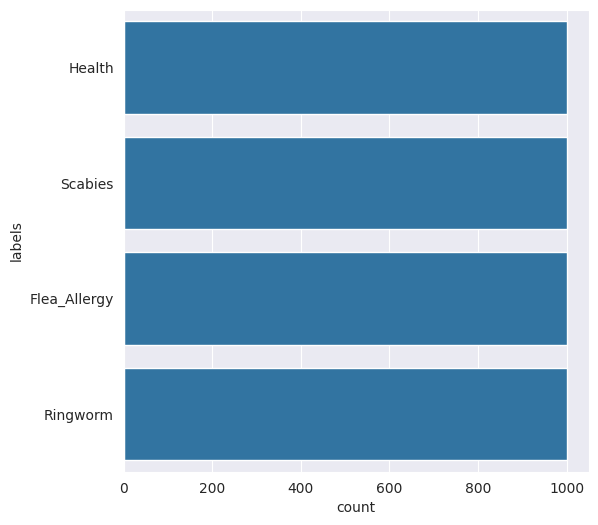

In [9]:
lung_path = "cat_skin_disease/dataset_augmented/"

# daftar menyimpan file
file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# plot jumlah gambar
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [10]:
mypath= 'cat_skin_disease/dataset_augmented/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

# melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
Flea_Allergy,1000
Health,1000
Ringworm,1000
Scabies,1000


In [11]:
X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [12]:
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [13]:
print('train size', len(df_tr))
print('test size', len(df_te))

train size 3200
test size 800


In [14]:
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

print(df_all.sample(5))


set    labels      
test   Flea_Allergy    197
       Health          212
       Ringworm        190
       Scabies         201
train  Flea_Allergy    803
       Health          788
       Ringworm        810
       Scabies         799
dtype: int64 


                                                   path        labels    set
1708  cat_skin_disease/dataset_augmented/Health/aug_...        Health  train
1635  cat_skin_disease/dataset_augmented/Health/aug_...        Health  train
967   cat_skin_disease/dataset_augmented/Scabies/aug...       Scabies  train
2017  cat_skin_disease/dataset_augmented/Health/aug_...        Health  train
1625  cat_skin_disease/dataset_augmented/Flea_Allerg...  Flea_Allergy  train


In [15]:
datasource_path = "cat_skin_disease/dataset_augmentation"
dataset_path = "Dataset-Final"

In [16]:
for index, row in tq(df_all.iterrows()):
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

In [17]:
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

train_f = os.path.join(TRAIN_DIR + '/Flea_Allergy')
train_h = os.path.join(TRAIN_DIR + '/Health')
train_r = os.path.join(TRAIN_DIR + '/Ringworm')
train_s = os.path.join(TRAIN_DIR + '/Scabies')

test_f = os.path.join(TEST_DIR + '/Flea_Allergy')
test_h = os.path.join(TEST_DIR + '/Health')
test_r = os.path.join(TEST_DIR + '/Ringworm')
test_s = os.path.join(TEST_DIR + '/Scabies')

print("Total number of Flea Allergy images in training set: ",len(os.listdir(train_f)))
print("Total number of Health images in training set: ",len(os.listdir(train_h)))
print("Total number of Ringworm images in training set: ",len(os.listdir(train_r)))
print("Total number of Scabies images in training set: ",len(os.listdir(train_s)))

print("Total number of Flea Allergy images in test set: ",len(os.listdir(test_f)))
print("Total number of Health images in test set: ",len(os.listdir(test_h)))
print("Total number of Ringworm images in test set: ",len(os.listdir(test_r)))
print("Total number of Scabies images in test set: ",len(os.listdir(test_s)))

Total number of Flea Allergy images in training set:  803
Total number of Health images in training set:  788
Total number of Ringworm images in training set:  810
Total number of Scabies images in training set:  799
Total number of Flea Allergy images in test set:  197
Total number of Health images in test set:  212
Total number of Ringworm images in test set:  190
Total number of Scabies images in test set:  201


In [18]:
from tensorflow.keras.applications.resnet50 import preprocess_input

class_type = 'categorical'

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    brightness_range=[0.8, 1.2],
    zoom_range=0.2,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

SEED = 42

# Train Generator
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=16,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode=class_type,
    subset='training',
    seed=SEED, # Tambahkan ini
    shuffle=True
)

# Validation Generator
validation_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=16,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode=class_type,
    subset='validation',
    seed=SEED, # Gunakan seed yang SAMA agar tidak ada data bocor (leakage)
    shuffle=False
)

# Test Generator
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode=class_type,
    shuffle=False
)

Found 2562 images belonging to 4 classes.
Found 638 images belonging to 4 classes.
Found 800 images belonging to 4 classes.


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50

# Load Pre-trained Model
base_model = ResNet50(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))

# Freeze Base Model (Agar bobot asli tidak rusak di awal latihan)
base_model.trainable = False

# Membangun Arsitektur Baru di Atasnya
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

# Menggabungkan Input Base Model dengan Output Baru
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,638,852 (93.99 MB)

 Trainable params: 1,051,140 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [20]:
import tensorflow as tf
import os

# early_stopping = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

checkpoint_path = "model_terbaik.keras"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Gabungkan semua ke dalam list
callbacks_list = [model_checkpoint, reduce_lr]

In [21]:
import os

# Ambil list semua folder di dalam TRAIN_DIR
categories = list(train_generator.class_indices.keys())
total_files = 0
counts = {}

# Hitung jumlah file per kategori
for cat in categories:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cat)))
    counts[train_generator.class_indices[cat]] = count
    total_files += count

# Hitung weight: (Total / (Jumlah Kelas * Jumlah Gambar Per Kelas))
num_classes = len(categories)
class_weights = {}

for cls_idx, count in counts.items():
    weight = total_files / (num_classes * count)
    class_weights[cls_idx] = weight

print("Class Weights:", class_weights)


%time
history = model.fit(train_generator,
                        epochs=50,
                        batch_size=32,
                        validation_data=validation_generator,
                        callbacks=callbacks_list,
                        class_weight = class_weights)

Class Weights: {0: 0.9962640099626401, 1: 1.015228426395939, 2: 0.9876543209876543, 3: 1.0012515644555695}
CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 7.63 µs
Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.6550 - loss: 1.1532
Epoch 1: val_loss improved from None to 0.41188, saving model to model_terbaik.keras

Epoch 1: finished saving model to model_terbaik.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 75s 380ms/step - accuracy: 0.7557 - loss: 0.7388 - val_accuracy: 0.8417 - val_loss: 0.4119 - learning_rate: 0.0010
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.8642 - loss: 0.3690
Epoch 2: val_loss improved from 0.41188 to 0.35345, saving model to model_terbaik.keras

Epoch 2: finished saving model to model_terbaik.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 49s 301ms/step - accuracy: 0.8583 - loss: 0.3797 - val_accuracy: 0.8809 - val_loss: 0.3534 - learning_rate: 0.0010
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.8726 - loss: 0

Loading the best model weights...
Best Epoch found at: 18


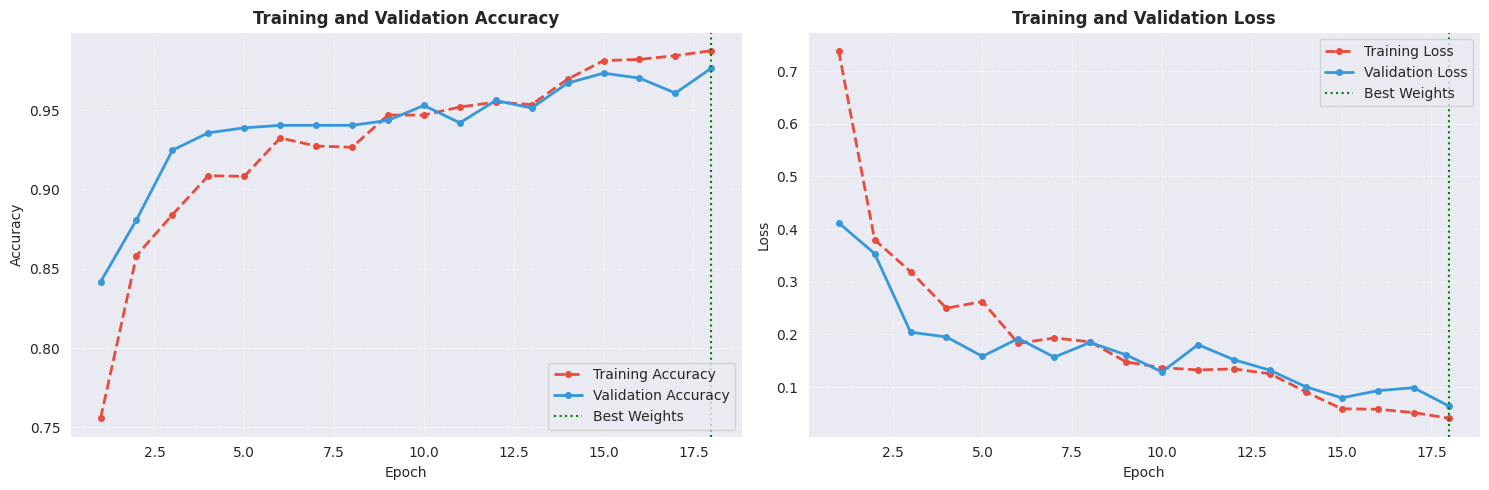


Final Test Accuracy to report: 98.37%


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load model terbaik
print("Loading the best model weights...")
model_final = tf.keras.models.load_model('model_terbaik.keras')

# Ambil titik terbaik (Best Epoch)
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"Best Epoch found at: {best_epoch}")

acc = history.history['accuracy'][:best_epoch]
val_acc = history.history['val_accuracy'][:best_epoch]
loss = history.history['loss'][:best_epoch]
val_loss = history.history['val_loss'][:best_epoch]

epochs_range = range(1, best_epoch + 1)

# --- VISUALISASI ---
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy (Merah vs Biru)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#e74c3c', linewidth=2, marker='o', markersize=4, linestyle='--')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#3498db', linewidth=2, marker='o', markersize=4)
plt.axvline(x=best_epoch, color='green', linestyle=':', label=f'Best Weights')

plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Loss (Merah vs Biru)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#e74c3c', linewidth=2, marker='o', markersize=4, linestyle='--')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#3498db', linewidth=2, marker='o', markersize=4)
plt.axvline(x=best_epoch, color='green', linestyle=':', label=f'Best Weights')

plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('grafik_skripsi_clean.png', dpi=300)
plt.show()

# Evaluasi angka final untuk teks laporan
test_generator.reset()
_, final_acc = model_final.evaluate(test_generator, verbose=0)
print(f"\nFinal Test Accuracy to report: {final_acc*100:.2f}%")

Loading the best model for final evaluation...
Predicting on test data...
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step


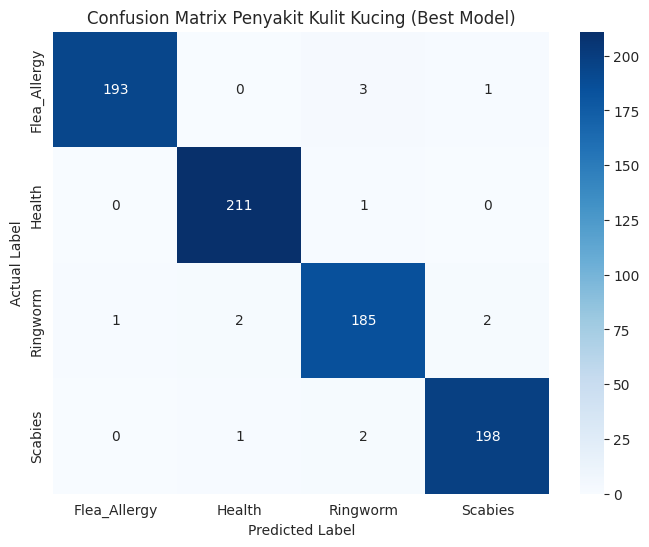


Classification Report (Based on model_terbaik.keras):

              precision    recall  f1-score   support

Flea_Allergy     0.9948    0.9797    0.9872       197
      Health     0.9860    0.9953    0.9906       212
    Ringworm     0.9686    0.9737    0.9711       190
     Scabies     0.9851    0.9851    0.9851       201

    accuracy                         0.9838       800
   macro avg     0.9836    0.9834    0.9835       800
weighted avg     0.9838    0.9838    0.9838       800



In [23]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load model terbaik secara utuh
print("Loading the best model for final evaluation...")
model_final = tf.keras.models.load_model('model_terbaik.keras')

# Reset generator agar urutan data test tidak berantakan
test_generator.reset()

# Prediksi menggunakan model_final
print("Predicting on test data...")
preds = model_final.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# Ambil class names
class_names = list(test_generator.class_indices.keys())

# Print Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Penyakit Kulit Kucing (Best Model)")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# Print Classification Report
print("\nClassification Report (Based on model_terbaik.keras):\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Saving images.jpg to images.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Analisis Gambar images.jpg:
Flea_Allergy: 0.00%
Health: 0.01%
Ringworm: 99.95%
Scabies: 0.04%


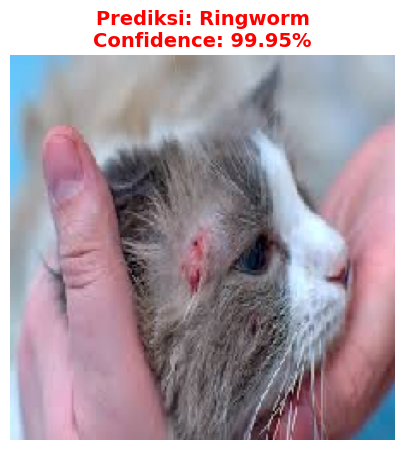

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Ambil label dari generator
labels = list(train_generator.class_indices.keys())

# Load model terbaik
model_final = tf.keras.models.load_model('model_terbaik.keras')

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Preprocessing WAJIB sama dengan saat training (ResNet50)
    x = preprocess_input(x)

    # Prediksi menggunakan model terbaik
    predictions = model_final.predict(x)
    score = np.max(predictions[0])
    class_idx = np.argmax(predictions[0])
    label_name = labels[class_idx]

    print(f"\nAnalisis Gambar {fn}:")
    for i, label in enumerate(labels):
        print(f"{label}: {predictions[0][i]*100:.2f}%")

    # Warna judul: Hijau untuk Health, Merah untuk penyakit
    color = 'green' if label_name == 'Health' else 'red'

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediksi: {label_name}\nConfidence: {score*100:.2f}%",
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

Saving stock-photo-the-cat-with-clinical-sign-of-feline-sarcoptic-mange-infection-sarcoptic-mange-or-scabies-is-a-1008995257.jpg to stock-photo-the-cat-with-clinical-sign-of-feline-sarcoptic-mange-infection-sarcoptic-mange-or-scabies-is-a-1008995257.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Analisis Gambar stock-photo-the-cat-with-clinical-sign-of-feline-sarcoptic-mange-infection-sarcoptic-mange-or-scabies-is-a-1008995257.jpg:
Flea_Allergy: 0.00%
Health: 0.00%
Ringworm: 0.00%
Scabies: 100.00%


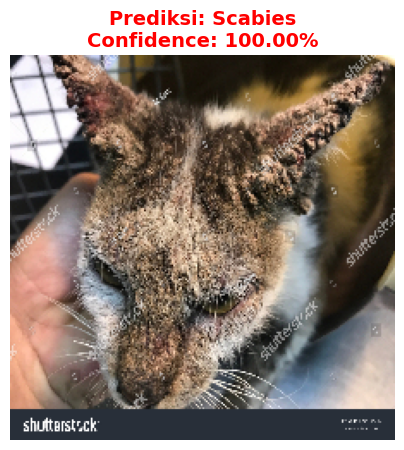

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Ambil label dari generator
labels = list(train_generator.class_indices.keys())

# Load model terbaik
model_final = tf.keras.models.load_model('model_terbaik.keras')

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Preprocessing WAJIB sama dengan saat training (ResNet50)
    x = preprocess_input(x)

    # Prediksi menggunakan model terbaik
    predictions = model_final.predict(x)
    score = np.max(predictions[0])
    class_idx = np.argmax(predictions[0])
    label_name = labels[class_idx]

    print(f"\nAnalisis Gambar {fn}:")
    for i, label in enumerate(labels):
        print(f"{label}: {predictions[0][i]*100:.2f}%")

    # Warna judul: Hijau untuk Health, Merah untuk penyakit
    color = 'green' if label_name == 'Health' else 'red'

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediksi: {label_name}\nConfidence: {score*100:.2f}%",
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

Saving Poodle-hotspot-care-000122_png.jpg to Poodle-hotspot-care-000122_png.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Analisis Gambar Poodle-hotspot-care-000122_png.jpg:
Flea_Allergy: 99.25%
Health: 0.00%
Ringworm: 0.75%
Scabies: 0.00%


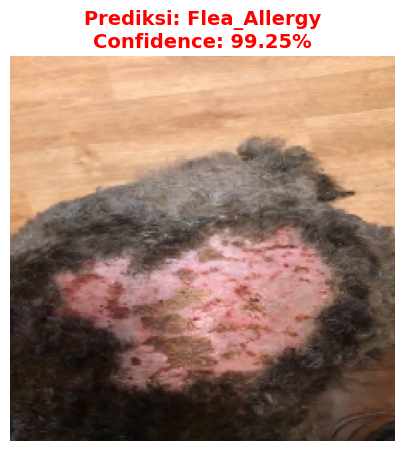

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Ambil label dari generator
labels = list(train_generator.class_indices.keys())

# Load model terbaik
model_final = tf.keras.models.load_model('model_terbaik.keras')

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Preprocessing WAJIB sama dengan saat training (ResNet50)
    x = preprocess_input(x)

    # Prediksi menggunakan model terbaik
    predictions = model_final.predict(x)
    score = np.max(predictions[0])
    class_idx = np.argmax(predictions[0])
    label_name = labels[class_idx]

    print(f"\nAnalisis Gambar {fn}:")
    for i, label in enumerate(labels):
        print(f"{label}: {predictions[0][i]*100:.2f}%")

    # Warna judul: Hijau untuk Health, Merah untuk penyakit
    color = 'green' if label_name == 'Health' else 'red'

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediksi: {label_name}\nConfidence: {score*100:.2f}%",
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

Saving images (1).jpg to images (1).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Analisis Gambar images (1).jpg:
Flea_Allergy: 0.00%
Health: 99.81%
Ringworm: 0.00%
Scabies: 0.19%


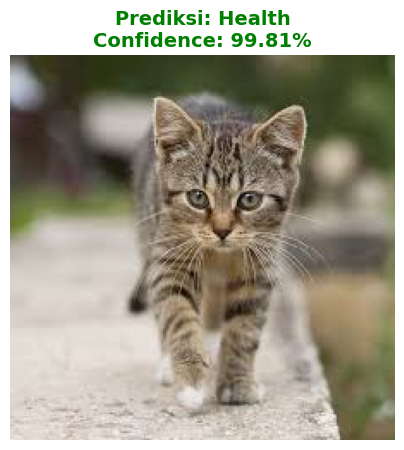

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Ambil label dari generator
labels = list(train_generator.class_indices.keys())

# Load model terbaik
model_final = tf.keras.models.load_model('model_terbaik.keras')

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Preprocessing WAJIB sama dengan saat training (ResNet50)
    x = preprocess_input(x)

    # Prediksi menggunakan model terbaik
    predictions = model_final.predict(x)
    score = np.max(predictions[0])
    class_idx = np.argmax(predictions[0])
    label_name = labels[class_idx]

    print(f"\nAnalisis Gambar {fn}:")
    for i, label in enumerate(labels):
        print(f"{label}: {predictions[0][i]*100:.2f}%")

    # Warna judul: Hijau untuk Health, Merah untuk penyakit
    color = 'green' if label_name == 'Health' else 'red'

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediksi: {label_name}\nConfidence: {score*100:.2f}%",
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

# Konversi Model

In [28]:
# save model
export_dir = "saved_model/"
model.export(export_dir)

Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135458945148752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945149520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945148944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945150096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945147216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945147792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945151440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945152784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945154704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945153936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135458945154128: T

In [29]:
import shutil

# zip folder
shutil.make_archive('saved_model', 'zip', export_dir)

'/content/saved_model.zip'

In [30]:
from google.colab import files

files.download('saved_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
keras_dir = "model_terbaik.keras"
files.download(keras_dir)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Requirement.txt

In [32]:
!pip freeze > requirements.txt